In [1]:
# import python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the data
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

In [3]:
# Peeking at the data
client_df.head()
price_df.head()
print(client_df.shape, price_df.shape)

(14606, 26) (193002, 8)


In [4]:
# Check data types and non-null counts
client_df.info()
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [5]:
# Descriptive statistics for number columns
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [6]:
# Descriptive statistics for text columns 
client_df.describe(include=['object', 'str'])

,id,channel_sales,date_activ,date_end,date_modif_prod,date_renewal,has_gas,origin_up
count,14606,14606,14606,14606,14606,14606,14606,14606
unique,14606,8,1796,368,2129,386,2,6
top,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,2009-08-01,2016-02-01,2015-11-01,2015-06-23,f,lxidpiddsbxsbosboudacockeimpuepw
freq,1,6754,95,145,721,587,11955,7097


In [7]:
# Counting Unique values
client_df.nunique()

id                                14606
channel_sales                         8
cons_12m                          11065
cons_gas_12m                       2112
cons_last_month                    4751
date_activ                         1796
date_end                            368
date_modif_prod                    2129
date_renewal                        386
forecast_cons_12m                 13993
forecast_cons_year                 4218
forecast_discount_energy             12
forecast_meter_rent_12m            3528
forecast_price_energy_off_peak      516
forecast_price_energy_peak          329
forecast_price_pow_off_peak          41
has_gas                               2
imp_cons                           7752
margin_gross_pow_ele               2391
margin_net_pow_ele                 2391
nb_prod_act                          10
net_margin                        11965
num_years_antig                      13
origin_up                             6
pow_max                             698


In [8]:
# Counting how often each value appears
client_df['churn'].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

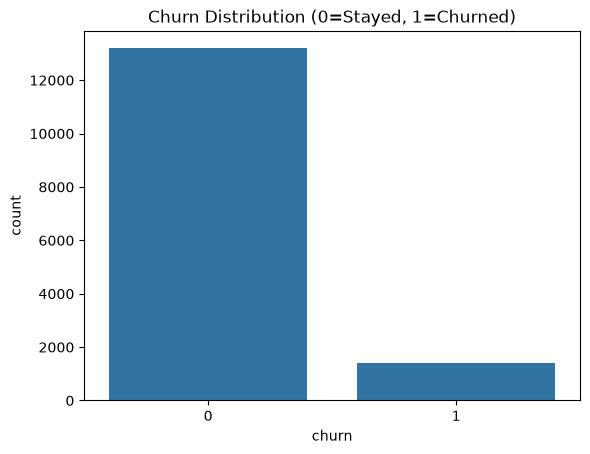

In [9]:
# Drawing a bar chart for churn 
sns.countplot(x='churn', data=client_df)
plt.title('Churn Distribution (0=Stayed, 1=Churned)')
plt.show()

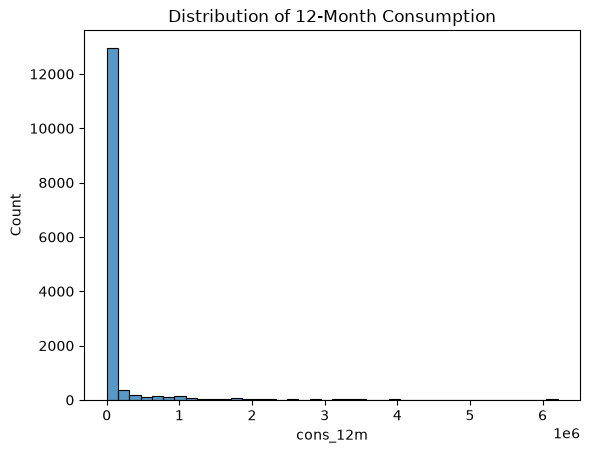

In [10]:
# Drawing a histogram for consumption
sns.histplot(client_df['cons_12m'],bins=40)
plt.title('Distribution of 12-Month Consumption')
plt.show()

In [11]:
# Check for missing values, including the hidden "MISSING" placeholder
print(client_df.isnull().sum())

for col in client_df.select_dtypes(include=['object', 'str']).columns:
    missing_count=(client_df[col]=='MISSING').sum()
    if missing_count > 0:
        print(f"{col}: {missing_count} rows marked as 'MISSING'")

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64
channel_sales: 3725 rows marked as 'MISSING'
origin

In [12]:
# Value counts for key columns
client_df['churn'].value_counts(normalize=True)
client_df['has_gas'].value_counts()
client_df['channel_sales'].value_counts()

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

In [13]:
# Remove redundant columns
client_df.nunique().sort_values()
print(client_df[['margin_gross_pow_ele', 'margin_net_pow_ele']].corr())
matches=(client_df['margin_gross_pow_ele'] == client_df['margin_net_pow_ele']).sum()
print(f"Exact matches: {matches} out of {len(client_df)}")

client_df = client_df.drop(columns=['margin_net_pow_ele'])

                      margin_gross_pow_ele  margin_net_pow_ele
margin_gross_pow_ele              1.000000            0.999914
margin_net_pow_ele                0.999914            1.000000
Exact matches: 14604 out of 14606


In [14]:
# Convert column to datetime format
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])

# Expand date column into year/month/day
client_df['activ_year'] = client_df['date_activ'].dt.year
client_df['activ_month'] = client_df['date_activ'].dt.month
client_df['activ_day'] = client_df['date_activ'].dt.day

In [15]:
# Force these columns into plain numeric format
price_df['price_off_peak_var'] = pd.to_numeric(price_df['price_off_peak_var'], errors='coerce')
price_df['price_peak_var'] = pd.to_numeric(price_df['price_peak_var'], errors='coerce')
price_df['price_mid_peak_var'] = pd.to_numeric(price_df['price_mid_peak_var'], errors='coerce')

In [16]:
price_df[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']].isnull().sum()

price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
dtype: int64

In [17]:
# Force these date columns into plain datetime format
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end'] = pd.to_datetime(client_df['date_end'])
client_df['date_modif_prod'] = pd.to_datetime(client_df['date_modif_prod'])
client_df['date_renewal'] = pd.to_datetime(client_df['date_renewal'])

In [18]:
# Combine columns into new features
client_df['tenure_days'] = (client_df['date_end'] - client_df['date_activ']).dt.days

price_df['total_price_var'] = (
    price_df['price_off_peak_var'] +
    price_df['price_peak_var'] +
    price_df['price_mid_peak_var']
)

In [19]:
# Merge the two datasets
merged_df = client_df.merge(price_df, on='id', how='left')
print(merged_df.shape)
merged_df.head()

(175149, 37)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,activ_day,tenure_days,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix,total_price_var
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,15,1096,2015-01-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389,0.300907
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,15,1096,2015-02-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389,0.300907
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,15,1096,2015-03-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,0.300907
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,15,1096,2015-04-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,0.300907
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,15,1096,2015-05-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383,0.300907


In [20]:
# Imports
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [21]:
# Load data fresh
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

In [22]:
# Fix column types
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col])

for col in ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']:
    price_df[col] = pd.to_numeric(price_df[col], errors='coerce')

In [23]:
# Average price per customer, then merge onto client data
price_agg = price_df.groupby('id').mean(numeric_only=True).reset_index()
price_agg.columns = ['id'] + ['avg_' + c for c in price_agg.columns if c != 'id']

merged_df = client_df.merge(price_agg, on='id', how='left')

In [24]:
# Convert everything into numbers, drop what the model can't use
merged_df = merged_df.drop(columns=date_cols + ['id'])
merged_df['has_gas'] = merged_df['has_gas'].map({'t': 1, 'f': 0})

cat_cols = merged_df.select_dtypes(include='object').columns.tolist()
merged_df = pd.get_dummies(merged_df, columns=cat_cols)

merged_df = merged_df.fillna(0)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_19076\2663243654.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = merged_df.select_dtypes(include='object').columns.tolist()


In [25]:
# Confirm it's clean before modeling (should both print True/0)
print("No text columns left:", merged_df.select_dtypes(include='object').shape[1] == 0)
print("No missing values left:", merged_df.isnull().sum().sum() == 0)

No text columns left: True
No missing values left: True


In [26]:
# Split into features (X) and target (y), then train/test sets
X = merged_df.drop(columns=['churn'])
y = merged_df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
# 1. DECISION TREE
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_predictions))

Decision Tree Accuracy: 0.837782340862423


In [28]:
# 2. RANDOM FOREST
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, forest_predictions))

Random Forest Accuracy: 0.8993839835728953


In [29]:
# 3. FEATURE IMPORTANCE
importances = pd.Series(forest_model.feature_importances_, index=X.columns)
top_10 = importances.sort_values(ascending=False).head(10)
print(top_10)

cons_12m                          0.076835
net_margin                        0.074493
forecast_meter_rent_12m           0.074214
forecast_cons_12m                 0.072112
margin_gross_pow_ele              0.065203
avg_price_off_peak_var            0.064780
margin_net_pow_ele                0.063334
cons_last_month                   0.051114
pow_max                           0.050547
forecast_price_energy_off_peak    0.047480
dtype: float64


## Summary of Findings

- **Churn rate:** About 9.7% of customers churned (1,419 out of 14,606) — a relatively low overall churn rate.
- **Strongest predictors:** Net margin and 12-month consumption were the most important features in the Random Forest model, based on feature importance scores. This suggests churn is more closely tied to how much a customer uses and how profitable they are, rather than price sensitivity.
- **Price sensitivity:** The engineered price-variance features (average and maximum price swing) did not rank as strong predictors, suggesting the original assumption that pricing volatility drives churn is not strongly supported by this data.
- **Model performance:** Accuracy was high (~91%), but this was misleading due to class imbalance — only ~10% of customers actually churned. Recall was low (~6.7%), meaning the model missed most actual churners. This indicates the model, in its current form, is not reliable enough to use for targeted retention outreach without further improvement (e.g. addressing class imbalance).
- **Conclusion:** Retention strategy should focus on customer segments with low margin and low consumption rather than a blanket price-based discount, though further model tuning would be needed before using these predictions operationally.